# RFM Segmentation

This notebook segments customers using RFM analysis: Recency, Frequency and Monetary value.  
The goal is to identify high-value, loyal, new and at-risk customer groups for business recommendations.

## Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

## Load Data

In [2]:
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

clean_path = ROOT_DIR / "data" / "processed" / "online_retail_clean.csv"
orders_path = ROOT_DIR / "data" / "processed" / "orders.csv"

df = pd.read_csv(clean_path, parse_dates=["invoice_date"])
orders = pd.read_csv(orders_path, parse_dates=["invoice_date"])

df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancelled,line_revenue,invoice_day,invoice_month,invoice_year,invoice_hour,day_of_week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010-12-01,2010-12,2010,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00,2010-12-01,2010-12,2010,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday


In [3]:
orders.head()

,invoice_no,customer_id,country,invoice_date,invoice_month,total_quantity,order_revenue,unique_products
0,536365,17850,United Kingdom,2010-12-01 08:26:00,2010-12,40,139.12,7
1,536366,17850,United Kingdom,2010-12-01 08:28:00,2010-12,12,22.20,2
2,536367,13047,United Kingdom,2010-12-01 08:34:00,2010-12,83,278.73,12
3,536368,13047,United Kingdom,2010-12-01 08:34:00,2010-12,15,70.05,4
4,536369,13047,United Kingdom,2010-12-01 08:35:00,2010-12,3,17.85,1


## Dataset Overview

In [4]:
overview = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Orders",
            "Customers",
            "Products",
            "Countries",
            "Total revenue",
            "Min invoice date",
            "Max invoice date",
        ],
        "value": [
            len(df),
            orders["invoice_no"].nunique(),
            df["customer_id"].nunique(),
            df["stock_code"].nunique(),
            df["country"].nunique(),
            df["line_revenue"].sum(),
            df["invoice_date"].min(),
            df["invoice_date"].max(),
        ],
    }
)

overview

,metric,value
0,Rows,397884
1,Orders,18532
2,Customers,4338
3,Products,3665
4,Countries,37
5,Total revenue,"8,911,407.90"
6,Min invoice date,2010-12-01 08:26:00
7,Max invoice date,2011-12-09 12:50:00


The cleaned dataset contains **397,884 transaction rows**, **18,532 orders**, **4,338 customers**, **3,665 products** and **£8.91M** in revenue for the period **2010-12-01 — 2011-12-09**.

## Build Customer-Level RFM Table

In [5]:
analysis_date = orders["invoice_date"].max() + pd.Timedelta(days=1)
analysis_date

Timestamp('2011-12-10 12:50:00')

In [6]:
rfm = (
    orders
    .groupby("customer_id", as_index=False)
    .agg(
        first_purchase_date=("invoice_date", "min"),
        last_purchase_date=("invoice_date", "max"),
        frequency=("invoice_no", "nunique"),
        monetary=("order_revenue", "sum"),
        avg_order_value=("order_revenue", "mean"),
        total_quantity=("total_quantity", "sum"),
        unique_products=("unique_products", "sum"),
    )
)

rfm["recency"] = (analysis_date - rfm["last_purchase_date"]).dt.days
rfm["customer_lifetime_days"] = (rfm["last_purchase_date"] - rfm["first_purchase_date"]).dt.days

rfm = rfm[
    [
        "customer_id",
        "first_purchase_date",
        "last_purchase_date",
        "recency",
        "frequency",
        "monetary",
        "avg_order_value",
        "total_quantity",
        "unique_products",
        "customer_lifetime_days",
    ]
].copy()

rfm.head()

,customer_id,first_purchase_date,last_purchase_date,recency,frequency,monetary,avg_order_value,total_quantity,unique_products,customer_lifetime_days
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,326,1,"77,183.60","77,183.60",74215,1,0
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,2,7,"4,310.00",615.71,2458,182,365
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,75,4,"1,797.24",449.31,2341,27,282
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,19,1,"1,757.55","1,757.55",631,73,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,310,1,334.40,334.40,197,17,0


In [7]:
rfm.describe()

,customer_id,first_purchase_date,last_purchase_date,recency,frequency,monetary,avg_order_value,total_quantity,unique_products,customer_lifetime_days
count,"4,338.00",4338,4338,"4,338.00","4,338.00","4,338.00","4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",2011-04-30 17:06:50.857538,2011-09-08 11:38:58.990318,92.54,4.27,"2,054.27",419.17,"1,191.29",89.41,130.45
min,"12,346.00",2010-12-01 08:26:00,2010-12-01 09:53:00,1.00,1.00,3.75,3.45,1.00,1.00,0.00
25%,"13,813.25",2011-01-17 11:13:15,2011-07-20 19:18:00,18.00,1.00,307.41,178.62,160.00,17.00,0.00
50%,"15,299.50",2011-04-05 09:52:30,2011-10-20 10:40:30,51.00,2.00,674.49,293.90,379.00,41.00,92.50
75%,"16,778.75",2011-08-19 10:11:30,2011-11-22 11:05:45,142.00,5.00,"1,661.74",430.11,992.75,97.00,251.75
max,"18,287.00",2011-12-09 12:16:00,2011-12-09 12:50:00,374.00,209.00,"280,206.02","84,236.25","196,915.00","7,477.00",373.00
std,"1,721.81",NaN,NaN,100.01,7.70,"8,989.23","1,796.54","5,046.08",222.25,132.04


The average customer made **4.27 orders** and generated **£2,054.27** in revenue. Median customer revenue is much lower (**£674.49**), which indicates a strong concentration of revenue among high-value customers. Median recency is **51 days**, while average recency is **92.54 days**.

## RFM Score Calculation

In [8]:
def assign_rfm_score(series: pd.Series, labels: list[int]) -> pd.Series:
    """
    Assigns quintile-based scores.
    rank(method='first') is used to avoid qcut issues with duplicate values.
    """
    return pd.qcut(
        series.rank(method="first"),
        q=5,
        labels=labels
    ).astype(int)


rfm["r_score"] = assign_rfm_score(rfm["recency"], labels=[5, 4, 3, 2, 1])
rfm["f_score"] = assign_rfm_score(rfm["frequency"], labels=[1, 2, 3, 4, 5])
rfm["m_score"] = assign_rfm_score(rfm["monetary"], labels=[1, 2, 3, 4, 5])

rfm["rfm_score"] = (
    rfm["r_score"].astype(str)
    + rfm["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)

rfm["rfm_total_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

rfm.head()

,customer_id,first_purchase_date,last_purchase_date,recency,frequency,monetary,avg_order_value,total_quantity,unique_products,customer_lifetime_days,r_score,f_score,m_score,rfm_score,rfm_total_score
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,326,1,"77,183.60","77,183.60",74215,1,0,1,1,5,115,7
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,2,7,"4,310.00",615.71,2458,182,365,5,5,5,555,15
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,75,4,"1,797.24",449.31,2341,27,282,2,4,4,244,10
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,19,1,"1,757.55","1,757.55",631,73,0,4,1,4,414,9
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,310,1,334.40,334.40,197,17,0,1,1,2,112,4


In [9]:
rfm_score_summary = (
    rfm[["r_score", "f_score", "m_score", "rfm_total_score"]]
    .describe()
)

rfm_score_summary

,r_score,f_score,m_score,rfm_total_score
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,3.00,3.00,3.00,9.00
std,1.41,1.41,1.41,3.59
min,1.00,1.00,1.00,3.00
25%,2.00,2.00,2.00,6.00
50%,3.00,3.00,3.00,9.00
75%,4.00,4.00,4.00,12.00
max,5.00,5.00,5.00,15.00


RFM scores range from **3** to **15**, with a median total score of **9**. Customers with scores close to **15** are the strongest segment candidates because they combine recent purchases, high frequency and high monetary value.

## Customer Segments

In [10]:
def assign_segment(row) -> str:
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"
    if r >= 4 and f <= 2:
        return "New Customers"
    if r >= 4 and f == 3:
        return "Potential Loyalists"
    if r <= 2 and f >= 4 and m >= 4:
        return "At Risk High Value"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r <= 2 and f <= 2 and m <= 2:
        return "Lost / Low Value"
    if m >= 4:
        return "Big Spenders"
    return "Regular Customers"


rfm["segment"] = rfm.apply(assign_segment, axis=1)

rfm.head()

,customer_id,first_purchase_date,last_purchase_date,recency,frequency,monetary,avg_order_value,total_quantity,unique_products,customer_lifetime_days,r_score,f_score,m_score,rfm_score,rfm_total_score,segment
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,326,1,"77,183.60","77,183.60",74215,1,0,1,1,5,115,7,Big Spenders
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,2,7,"4,310.00",615.71,2458,182,365,5,5,5,555,15,Champions
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,75,4,"1,797.24",449.31,2341,27,282,2,4,4,244,10,At Risk High Value
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,19,1,"1,757.55","1,757.55",631,73,0,4,1,4,414,9,New Customers
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,310,1,334.40,334.40,197,17,0,1,1,2,112,4,Lost / Low Value


## Segment Summary

In [11]:
segment_summary = (
    rfm
    .groupby("segment", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        total_revenue=("monetary", "sum"),
        avg_revenue_per_customer=("monetary", "mean"),
        avg_order_value=("avg_order_value", "mean"),
    )
)

segment_summary["customer_share"] = segment_summary["customers"] / segment_summary["customers"].sum()
segment_summary["revenue_share"] = segment_summary["total_revenue"] / segment_summary["total_revenue"].sum()

segment_summary = segment_summary.sort_values("total_revenue", ascending=False)

segment_summary

,segment,customers,avg_recency,avg_frequency,total_revenue,avg_revenue_per_customer,avg_order_value,customer_share,revenue_share
3,Champions,947,12.54,11.15,"5,755,513.22","6,077.63",467.26,0.22,0.65
5,Loyal Customers,454,38.63,5.32,"908,853.14","2,001.88",335.44,0.10,0.10
0,At Risk,488,160.16,2.67,"436,328.43",894.12,344.16,0.11,0.05
7,Potential Loyalists,304,15.78,2.34,"406,017.30","1,335.58",600.19,0.07,0.05
1,At Risk High Value,173,123.80,5.52,"390,109.94","2,254.97",435.07,0.04,0.04
2,Big Spenders,171,112.87,1.80,"382,682.44","2,237.91","1,608.24",0.04,0.04
8,Regular Customers,663,81.68,1.55,"298,101.87",449.63,339.69,0.15,0.03
4,Lost / Low Value,828,227.75,1.04,"190,632.99",230.23,223.44,0.19,0.02
6,New Customers,310,18.10,1.25,"143,168.57",461.83,363.40,0.07,0.02


In [12]:
segment_summary_for_display = segment_summary.copy()

segment_summary_for_display["customer_share"] = segment_summary_for_display["customer_share"].map("{:.1%}".format)
segment_summary_for_display["revenue_share"] = segment_summary_for_display["revenue_share"].map("{:.1%}".format)

segment_summary_for_display

,segment,customers,avg_recency,avg_frequency,total_revenue,avg_revenue_per_customer,avg_order_value,customer_share,revenue_share
3,Champions,947,12.54,11.15,"5,755,513.22","6,077.63",467.26,21.8%,64.6%
5,Loyal Customers,454,38.63,5.32,"908,853.14","2,001.88",335.44,10.5%,10.2%
0,At Risk,488,160.16,2.67,"436,328.43",894.12,344.16,11.2%,4.9%
7,Potential Loyalists,304,15.78,2.34,"406,017.30","1,335.58",600.19,7.0%,4.6%
1,At Risk High Value,173,123.80,5.52,"390,109.94","2,254.97",435.07,4.0%,4.4%
2,Big Spenders,171,112.87,1.80,"382,682.44","2,237.91","1,608.24",3.9%,4.3%
8,Regular Customers,663,81.68,1.55,"298,101.87",449.63,339.69,15.3%,3.3%
4,Lost / Low Value,828,227.75,1.04,"190,632.99",230.23,223.44,19.1%,2.1%
6,New Customers,310,18.10,1.25,"143,168.57",461.83,363.40,7.1%,1.6%


The strongest segment is **Champions**: **947 customers** (**21.8%**) generate **£5.76M** (**64.6%** of revenue). Together, **Champions** and **Loyal Customers** represent **1,401 customers** (**32.3%**) and generate **£6.66M** (**74.8%** of revenue).

## Segment Size

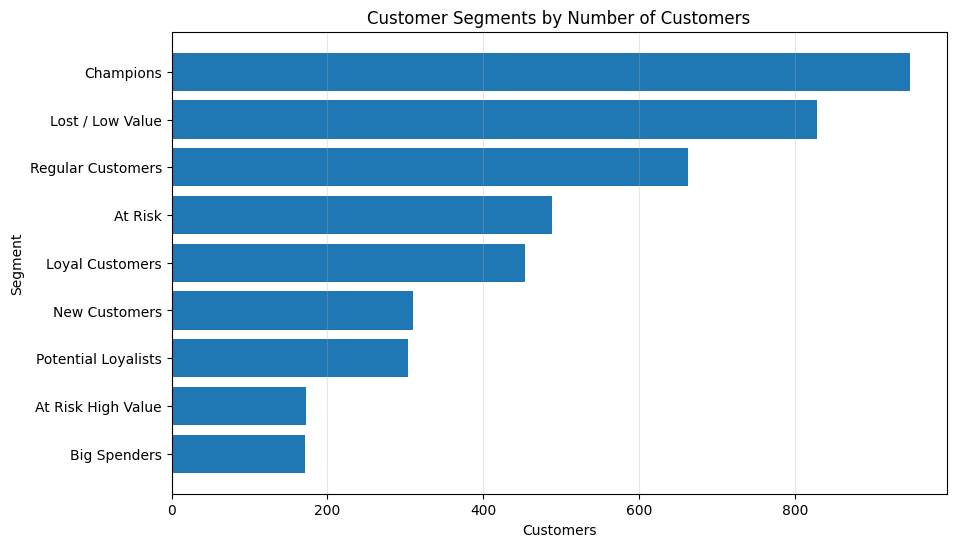

In [13]:
segment_size = segment_summary.sort_values("customers", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(segment_size["segment"], segment_size["customers"])
plt.title("Customer Segments by Number of Customers")
plt.xlabel("Customers")
plt.ylabel("Segment")
plt.grid(axis="x", alpha=0.3)
plt.show()

The largest segment is **Champions** with **947 customers**. At the same time, **Lost / Low Value** is also large: **828 customers** (**19.1%** of the base), but it generates only **2.1%** of revenue.

## Segment Revenue

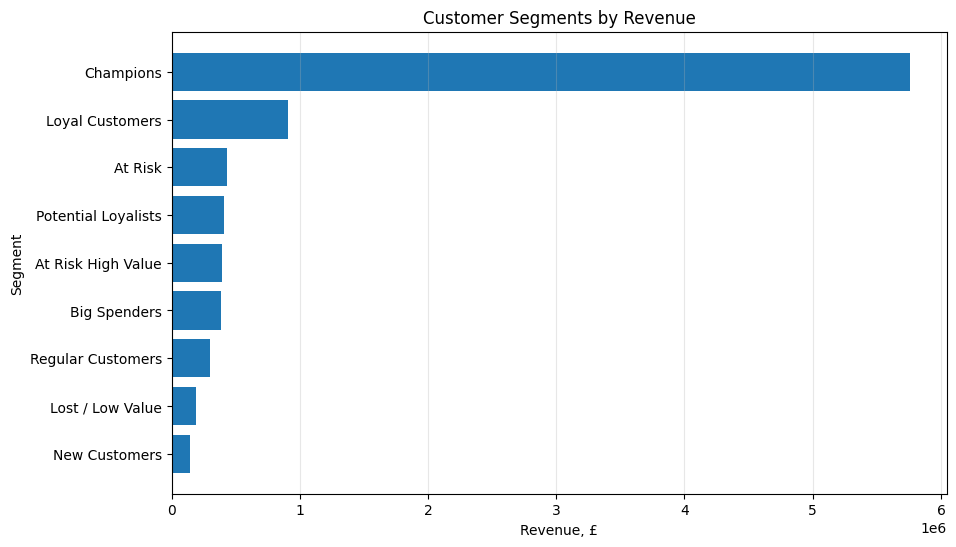

In [14]:
segment_revenue = segment_summary.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(segment_revenue["segment"], segment_revenue["total_revenue"])
plt.title("Customer Segments by Revenue")
plt.xlabel("Revenue, £")
plt.ylabel("Segment")
plt.grid(axis="x", alpha=0.3)
plt.show()

Revenue is highly concentrated in **Champions**. This segment alone generates **64.6%** of total revenue, while **Regular Customers**, **Lost / Low Value** and **New Customers** together represent **41.5%** of customers but only **7.0%** of revenue.

## Average Revenue per Customer by Segment

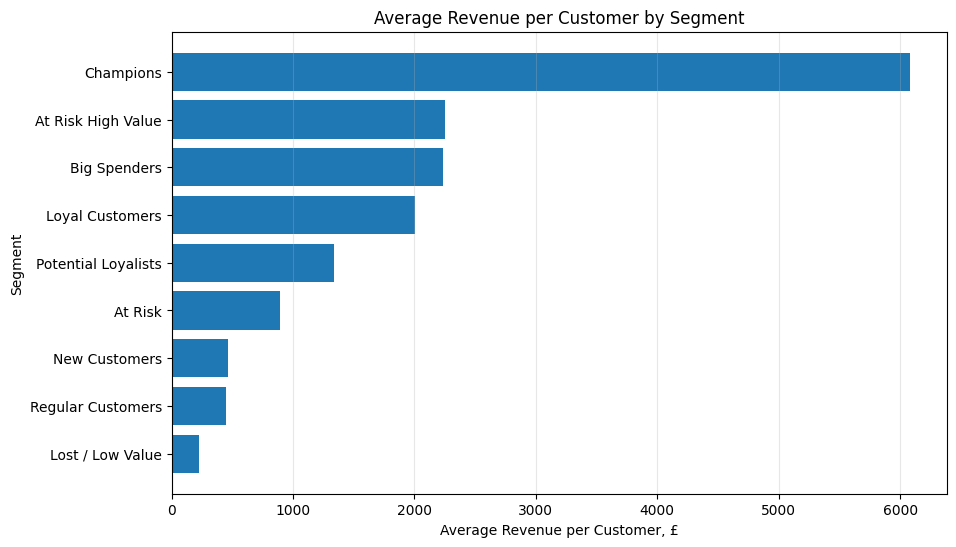

In [15]:
segment_arpc = segment_summary.sort_values("avg_revenue_per_customer", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(segment_arpc["segment"], segment_arpc["avg_revenue_per_customer"])
plt.title("Average Revenue per Customer by Segment")
plt.xlabel("Average Revenue per Customer, £")
plt.ylabel("Segment")
plt.grid(axis="x", alpha=0.3)
plt.show()

**Champions** have the highest average revenue per customer: **£6,077.63**. **At Risk High Value** and **Big Spenders** are also valuable segments with more than **£2,200** average revenue per customer, but both have high recency (**123.8** and **112.9** days), so they should be targeted with reactivation campaigns.

## RFM Matrix

In [16]:
rf_matrix = (
    rfm
    .groupby(["r_score", "f_score"], as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean"),
    )
)

rf_matrix_pivot = rf_matrix.pivot(
    index="r_score",
    columns="f_score",
    values="customers",
).sort_index(ascending=False)

rf_matrix_pivot

f_score,1,2,3,4,5
r_score,,,,,
5,42,57,136,194,439
4,95,116,168,245,243
3,166,185,188,208,121
2,199,208,234,173,53
1,366,301,142,47,12


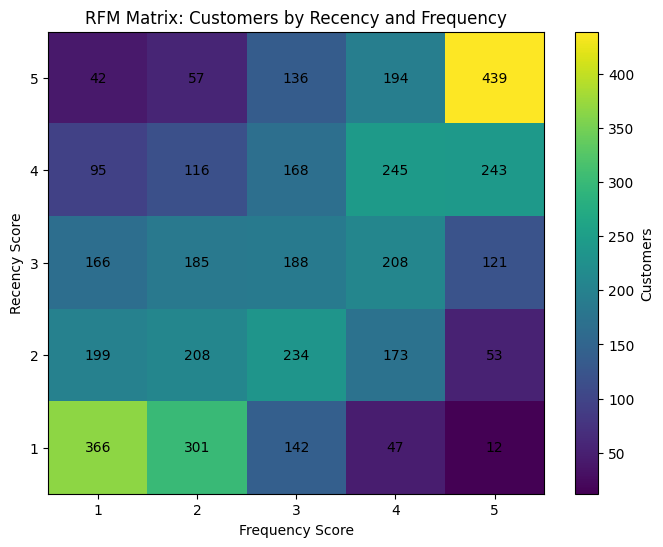

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(rf_matrix_pivot, aspect="auto")
plt.title("RFM Matrix: Customers by Recency and Frequency")
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")
plt.xticks(range(len(rf_matrix_pivot.columns)), rf_matrix_pivot.columns)
plt.yticks(range(len(rf_matrix_pivot.index)), rf_matrix_pivot.index)

for i in range(len(rf_matrix_pivot.index)):
    for j in range(len(rf_matrix_pivot.columns)):
        value = rf_matrix_pivot.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, int(value), ha="center", va="center")

plt.colorbar(label="Customers")
plt.show()

The best RFM cell (**R=5, F=5**) contains **439 customers**. The weakest cell (**R=1, F=1**) contains **366 customers**. There are **1,121 customers** with both high recency and high frequency scores (**R≥4, F≥4**).

## Top Customers by RFM

In [18]:
top_customers_rfm = (
    rfm
    .sort_values(
        ["rfm_total_score", "monetary", "frequency"],
        ascending=[False, False, False]
    )
    .head(20)
)

top_customers_rfm

,customer_id,first_purchase_date,last_purchase_date,recency,frequency,monetary,avg_order_value,total_quantity,unique_products,customer_lifetime_days,r_score,f_score,m_score,rfm_score,rfm_total_score,segment
1689,14646,2010-12-20 10:09:00,2011-12-08 12:12:00,2,73,"280,206.02","3,838.44",196915,2076,353,5,5,5,555,15,Champions
4201,18102,2010-12-07 16:42:00,2011-12-09 11:50:00,1,60,"259,657.30","4,327.62",64124,431,366,5,5,5,555,15,Champions
3728,17450,2010-12-07 09:23:00,2011-12-01 13:29:00,8,46,"194,550.79","4,229.36",69993,336,359,5,5,5,555,15,Champions
1879,14911,2010-12-01 14:05:00,2011-12-08 15:54:00,1,201,"143,825.06",715.55,80265,5670,372,5,5,5,555,15,Champions
1333,14156,2010-12-03 11:48:00,2011-11-30 10:54:00,10,55,"117,379.63","2,134.18",57885,1393,361,5,5,5,555,15,Champions
3771,17511,2010-12-01 10:19:00,2011-12-07 10:12:00,3,31,"91,062.38","2,937.50",64549,963,370,5,5,5,555,15,Champions
3176,16684,2010-12-16 17:34:00,2011-12-05 14:06:00,4,28,"66,653.56","2,380.48",50255,277,353,5,5,5,555,15,Champions
1289,14096,2011-08-30 10:49:00,2011-12-05 17:17:00,4,17,"65,164.79","3,833.22",16352,5080,97,5,5,5,555,15,Champions
996,13694,2010-12-01 12:12:00,2011-12-06 09:32:00,4,50,"65,039.62","1,300.79",63312,568,369,5,5,5,555,15,Champions
2176,15311,2010-12-01 09:41:00,2011-12-09 12:00:00,1,91,"60,767.90",667.78,38194,2357,373,5,5,5,555,15,Champions


The top customer by RFM revenue is **Customer 14646** with **£280,206.02**, **73 orders** and **2 days** recency. The top 10 RFM customers generate **£1.34M**, or **15.1%** of total revenue.

## Save Outputs

In [20]:
output_dir = ROOT_DIR / "data" / "processed"

rfm.to_csv(output_dir / "customers_rfm.csv", index=False)
segment_summary.to_csv(output_dir / "rfm_segment_summary.csv", index=False)
rf_matrix.to_csv(output_dir / "rf_matrix.csv", index=False)

print("Saved files:")
print(output_dir / "customers_rfm.csv")
print(output_dir / "rfm_segment_summary.csv")
print(output_dir / "rf_matrix.csv")

Saved files:
D:\pychramProjects\E-commerce-Analytics\data\processed\customers_rfm.csv
D:\pychramProjects\E-commerce-Analytics\data\processed\rfm_segment_summary.csv
D:\pychramProjects\E-commerce-Analytics\data\processed\rf_matrix.csv
D:\pychramProjects\E-commerce-Analytics\data\processed\rfm_segment_recommendations.csv


## Findings

RFM analysis confirms that revenue is driven by a relatively small group of high-value repeat customers. 
**Champions** make up **21.8%** of customers but generate **64.6%** of revenue, while **Champions + Loyal Customers** generate **74.8%** of revenue. 

The main business opportunity is to retain VIP customers, convert **Potential Loyalists** into repeat buyers and reactivate **At Risk High Value** customers before they become lost.